# **Question 2:**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# define the function 
def f(t,y):
    return y*t**2 - 1.1*y

# define the analytic solution with IV y(0) = 1
def y(t):
    return np.exp((t**3)/3 - 1.1*t)


In [4]:
# make a list of step sizes
step_size = [0.5,0.25,0.125,0.0625,0.03125]
i =0

In [5]:
# Create a folder to save the plots named "figures" in the current directory q2
import os
if not os.path.exists('figures'):
    os.makedirs('figures')
    

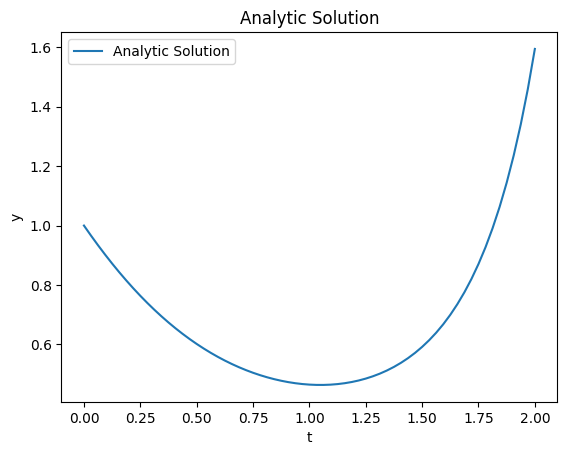

In [6]:
# loop over the step sizes to generate the empty arrays for the analytic solution for each step size
y_analytic =[]
for h in step_size:
    t = np.arange(0,2+h,h)
    y_analytic_h = np.zeros(len(t))
    y_analytic_h[0] = 1
    for j in range(1,len(t)):
        y_analytic_h[j] = y(t[j])
    y_analytic.append(y_analytic_h)
# plot the analytic solution for least step size
least_step_size = step_size[-1]
t = np.arange(0,2+least_step_size,least_step_size)
plt.plot(t,y(t),label = 'Analytic Solution')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Analytic Solution')
plt.legend()
# Save the plot in the figures folder
plt.savefig('figures/Analytic_solution.png')
plt.show()



In [8]:
#  Numerical solution saved in a list and read from the output files in the results folder
import os
# Define the path to the results folder
results_folder = 'results'

# Initialize lists to store the numerical solutions for each step size
euler_solutions = []
ab_solutions = []
rk_solutions = []

# Function to read numerical solutions from a file and split by empty lines
def read_solutions(file_path):
    solutions = []
    current_list = []
    with open(file_path, 'r') as file:
        for line in file:
            if line.strip() == "":
                if current_list:
                    solutions.append(current_list)
                    current_list = []
            else:
                # Split the line and extract the numerical solution
                parts = line.split()
                if len(parts) > 0 and parts[0] == "Numerical":
                    solution = float(parts[-1])
                    current_list.append(solution)
    if current_list:
        solutions.append(current_list)
    return solutions

# Read the output files in the results folder
for filename in os.listdir(results_folder):
    file_path = os.path.join(results_folder, filename)
    if 'Explicit_Euler_method' in filename:
        euler_solutions.extend(read_solutions(file_path))
    elif 'Second_order_Adam_Bashforth_method' in filename:
        ab_solutions.extend(read_solutions(file_path))
    elif 'Runge_Kutta_2nd_order_method' in filename:
        rk_solutions.extend(read_solutions(file_path))


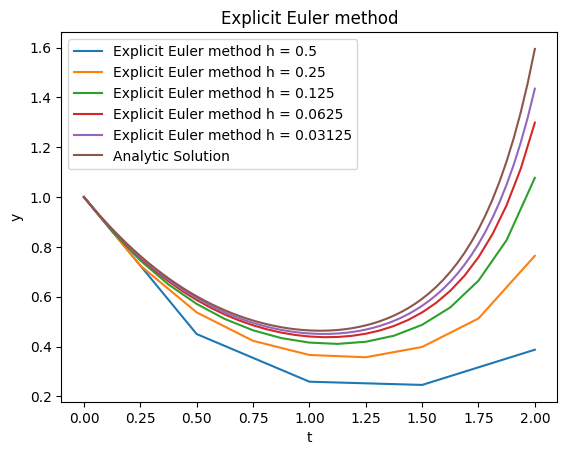

In [9]:
# plot the numerical solution for each step size and compare with the analytic solution for each method
# Explicit Euler method
for i in range(len(euler_solutions)):
    t = np.arange(0,2+step_size[i],step_size[i])
    plt.plot(t,euler_solutions[i],label = 'Explicit Euler method h = '+str(step_size[i]))
plt.plot(t,y(t),label = 'Analytic Solution')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Explicit Euler method')
plt.legend()
# Save the plot in the figures folder
plt.savefig('figures/Explicit_Euler_method.png')
plt.show()

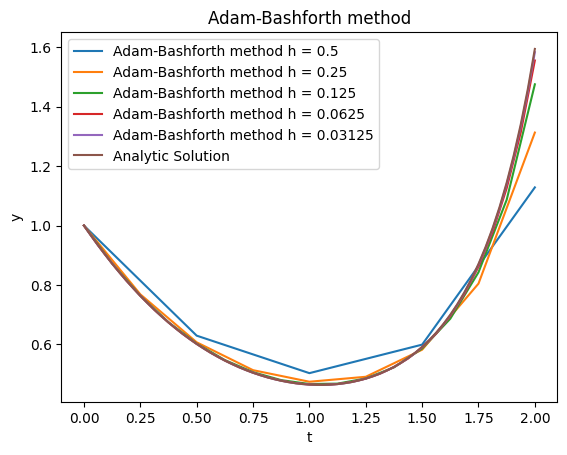

In [10]:
# Adam-Bashforth method
for i in range(len(ab_solutions)):
    t = np.arange(0,2+step_size[i],step_size[i])
    plt.plot(t,ab_solutions[i],label = 'Adam-Bashforth method h = '+str(step_size[i]))
plt.plot(t,y(t),label = 'Analytic Solution')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Adam-Bashforth method')
plt.legend()
# Save the plot in the figures folder
plt.savefig('figures/Adam_Bashforth_method.png')
plt.show()


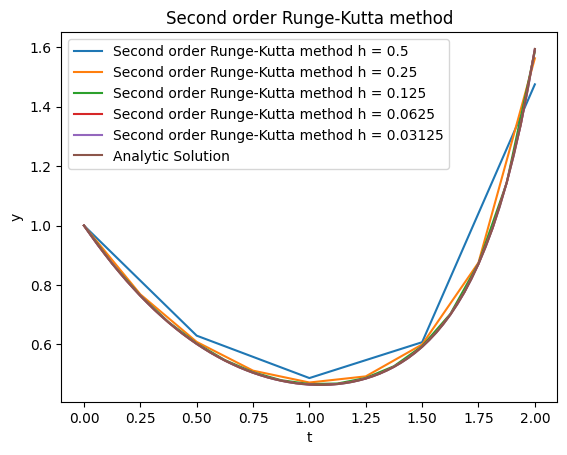

In [11]:
# Second order Runge-Kutta method
for i in range(len(rk_solutions)):
    t = np.arange(0,2+step_size[i],step_size[i])
    plt.plot(t,rk_solutions[i],label = 'Second order Runge-Kutta method h = '+str(step_size[i]))
plt.plot(t,y(t),label = 'Analytic Solution')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Second order Runge-Kutta method')
plt.legend()
# Save the plot in the figures folder
plt.savefig('figures/Second_order_Runge_Kutta_method.png')
plt.show()


In [12]:
# calculate the maximum and average absolute errors when compared with analytic solution array y_analytic for each step size for each method and store in the different  lists for each step size
max_errors_euler = []
max_errors_ab = []
max_errors_rk = []
abs_errors_euler = []
abs_errors_ab = []
abs_errors_rk = []
for i in range(len(step_size)):
    max_error_euler = np.max(np.abs(np.array(euler_solutions[i]) - y_analytic[i]))
    max_errors_euler.append(max_error_euler)
    max_error_ab = np.max(np.abs(np.array(ab_solutions[i]) - y_analytic[i]))
    max_errors_ab.append(max_error_ab)
    max_error_rk = np.max(np.abs(np.array(rk_solutions[i]) - y_analytic[i]))
    max_errors_rk.append(max_error_rk)
    abs_error_euler = np.mean(np.abs(np.array(euler_solutions[i]) - y_analytic[i]))
    abs_errors_euler.append(abs_error_euler)
    abs_error_ab = np.mean(np.abs(np.array(ab_solutions[i]) - y_analytic[i]))
    abs_errors_ab.append(abs_error_ab)
    abs_error_rk = np.mean(np.abs(np.array(rk_solutions[i]) - y_analytic[i]))
    abs_errors_rk.append(abs_error_rk)
 # Store the maximum and average absolute errors for each method in a text file in the results folder
 # Explicit Euler method
with open(os.path.join(results_folder, 'Explicit_Euler_method_errors.txt'), 'w') as file:
    file.write("Step Size\tMax Error\tAverage Error\n")
    for i in range(len(step_size)):
        file.write("{:.5f}\t\t{:.5f}\t\t{:.5f}\n".format(step_size[i], max_errors_euler[i], abs_errors_euler[i]))
        
# Adam-Bashforth method
with open(os.path.join(results_folder, 'Second_order_Adam_Bashforth_method_errors.txt'), 'w') as file:
    file.write("Step Size\tMax Error\tAverage Error\n")
    for i in range(len(step_size)):
        file.write("{:.5f}\t\t{:.5f}\t\t{:.5f}\n".format(step_size[i], max_errors_ab[i], abs_errors_ab[i]))

# Runge-Kutta method
with open(os.path.join(results_folder, 'Runge_Kutta_2nd_order_method_errors.txt'), 'w') as file:
    file.write("Step Size\tMax Error\tAverage Error\n")
    for i in range(len(step_size)):
        file.write("{:.5f}\t\t{:.5f}\t\t{:.5f}\n".format(step_size[i], max_errors_rk[i], abs_errors_rk[i]))


# print the maximum and average absolute errors for each step size for each method
# print("Max Errors for Euler Method:", max_errors_euler)
# print("Average Errors for Euler Method:", abs_errors_euler)
# print("Max Errors for Adam-Bashforth Method:", max_errors_ab)
# print("Average Errors for Adam-Bashforth Method:", abs_errors_ab)
# print("Max Errors for Runge-Kutta Method:", max_errors_rk)
# print("Average Errors for Runge-Kutta Method:", abs_errors_rk)



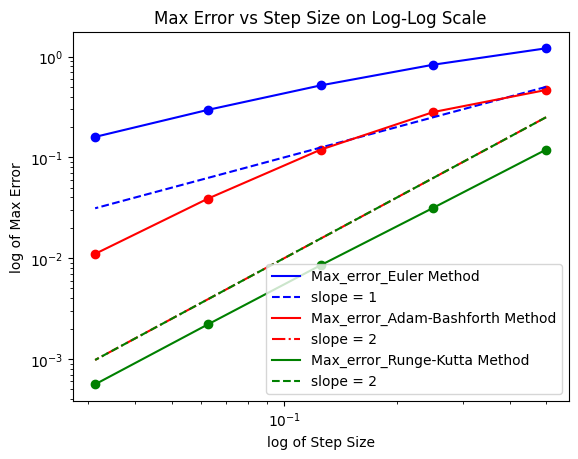

In [13]:
#  plot the maximum absolute errors for each method showing the order of accuracy
plt.plot(step_size,max_errors_euler,label = 'Max_error_Euler Method',color = 'blue')
# plot the dashed line with slope 1
plt.plot(step_size,step_size,label = 'slope = 1',linestyle = '--' ,color = 'blue')
plt.plot(step_size,max_errors_ab,label = 'Max_error_Adam-Bashforth Method',color = 'red')
# plot the dashed line with slope 2
plt.plot(step_size,np.array(step_size)**2,label = 'slope = 2',linestyle = '-.', color = 'red')
plt.plot(step_size,max_errors_rk,label = 'Max_error_Runge-Kutta Method',color = 'green')
# plot the dashed line with slope 2
plt.plot(step_size,np.array(step_size)**2,label = 'slope = 2',linestyle = '--', color = 'green')
plt.scatter(step_size,max_errors_euler, color = 'blue')
plt.scatter(step_size,max_errors_ab, color = 'red')
plt.scatter(step_size,max_errors_rk, color = 'green')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('log of Step Size')
plt.ylabel('log of Max Error')
plt.title('Max Error vs Step Size on Log-Log Scale')
plt.legend()
# Save the plot in the figures folder
plt.savefig('figures/Max_Error_vs_Step_Size.png')
plt.show()
# mark the step_sizes in the plot
# for i in range(len(step_size)):
#     plt.text(step_size[i],max_errors_euler[i],step_size[i], fontsize = 10 , color = 'black')
#     plt.text(step_size[i],max_errors_ab[i],step_size[i], fontsize = 10 , color = 'black')
#     plt.text(step_size[i],max_errors_rk[i],step_size[i], fontsize = 10 , color = 'black')


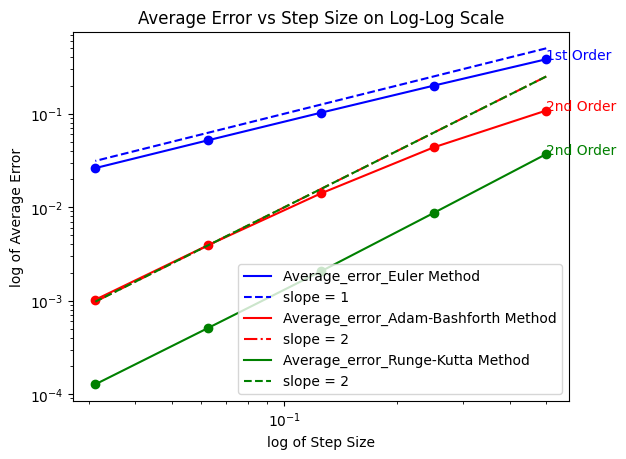

In [14]:
# plot the average absolute errors for each method showing the order of accuracy
plt.plot(step_size,abs_errors_euler,label = 'Average_error_Euler Method',color = 'blue')
plt.plot(step_size,step_size,label = 'slope = 1',linestyle = '--' ,color = 'blue')
plt.plot(step_size,abs_errors_ab,label = 'Average_error_Adam-Bashforth Method',color = 'red')
plt.plot(step_size,np.array(step_size)**2,label = 'slope = 2',linestyle = '-.', color = 'red')
plt.plot(step_size,abs_errors_rk,label = 'Average_error_Runge-Kutta Method',color = 'green')
plt.plot(step_size,np.array(step_size)**2,label = 'slope = 2',linestyle = '--', color = 'green')
# mark the order of accuracy for each method
plt.text(step_size[0],abs_errors_euler[0],'1st Order', fontsize = 10 , color = 'blue')
plt.text(step_size[0],abs_errors_ab[0],'2nd Order', fontsize = 10 , color = 'red')
plt.text(step_size[0],abs_errors_rk[0],'2nd Order', fontsize = 10 , color = 'green')
# mark the step_sizes and corresponding average errors on X and Y axis respectively
plt.scatter(step_size,abs_errors_euler, color = 'blue')
plt.scatter(step_size,abs_errors_ab, color = 'red')
plt.scatter(step_size,abs_errors_rk, color = 'green')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('log of Step Size')
plt.ylabel('log of Average Error')
plt.title('Average Error vs Step Size on Log-Log Scale')
plt.legend()
# Save the plot in the figures folder
plt.savefig('figures/Average_Error_vs_Step_Size.png')
plt.show()



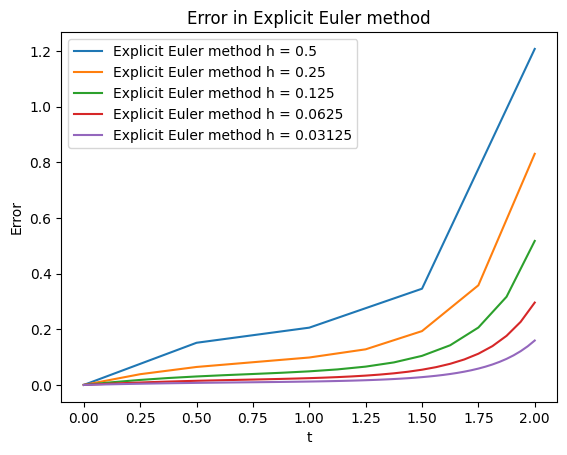

In [15]:
# plot error vs t for each method for each step size
# Explicit Euler method
for i in range(len(euler_solutions)):
    t = np.arange(0,2+step_size[i],step_size[i])
    plt.plot(t,np.abs(np.array(euler_solutions[i]) - y_analytic[i]),label = 'Explicit Euler method h = '+str(step_size[i]))
plt.xlabel('t')
plt.ylabel('Error')
plt.title('Error in Explicit Euler method')
plt.legend()
# Save the plot in the figures folder
plt.savefig('figures/Error_Explicit_Euler_method.png')
plt.show()


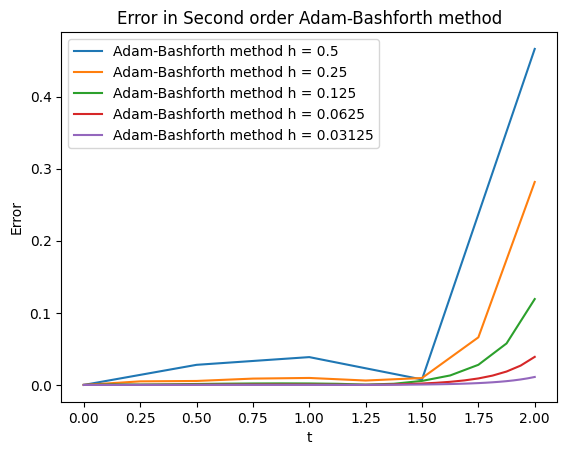

In [16]:
# Second order Adam-Bashforth method
for i in range(len(ab_solutions)):
    t = np.arange(0,2+step_size[i],step_size[i])
    plt.plot(t,np.abs(np.array(ab_solutions[i]) - y_analytic[i]),label = 'Adam-Bashforth method h = '+str(step_size[i]))
plt.xlabel('t')
plt.ylabel('Error')
plt.title('Error in Second order Adam-Bashforth method')
plt.legend()
# Save the plot in the figures folder
plt.savefig('figures/Error_Adam_Bashforth_method.png')
plt.show()


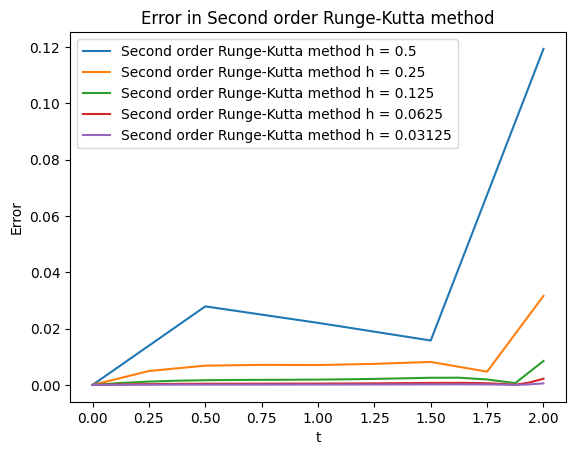

In [17]:
# Second order Runge-Kutta method
for i in range(len(rk_solutions)):
    t = np.arange(0,2+step_size[i],step_size[i])
    plt.plot(t,np.abs(np.array(rk_solutions[i]) - y_analytic[i]),label = 'Second order Runge-Kutta method h = '+str(step_size[i]))
plt.xlabel('t')
plt.ylabel('Error')
plt.title('Error in Second order Runge-Kutta method')
plt.legend()
# Save the plot in the figures folder
plt.savefig('figures/Error_Runge_Kutta_method.png')
plt.show()
